In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from examples.seismic import SeismicModel, AcquisitionGeometry
from examples.seismic.acoustic import AcousticWaveSolver, EikonalSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info

PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = path = "../data/21-20.sgy"
SO = 4
WAVELET = "Ricker"
NBL = 500
NFKL = 100
FS = False

slic = NBL - NFKL
slices = (slice(None), slice(slic, -slic), slice(None, -slic)) if FS else (slice(None), slice(slic, -slic), slice(slic, -slic))


dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
spacing = (0.025, 0.025)
velmodel = VelocityModel(PATH_MODEL, dx=spacing[0], dz=spacing[1], clip=True, xmin=xmin-3, xmax=xmax+3, zmin=-318)
velmodel.pad_left(4)
velmodel.pad_right(8*int(0.5/spacing[0]))
velmodel.pad_bottom(10*int(0.5/spacing[0]))
velmodel.pad_top(7*int(0.5/spacing[0]))

origin = velmodel.x[0], velmodel.z[0]
vp = velmodel.vp.T

model = SeismicModel(
    vp=vp,
    origin=origin,
    shape=vp.shape,
    spacing=spacing,
    space_order=SO,
    nbl=NBL,
    bcs="damp",
    fs=False,
)
t0 = 0.0
tn = dataset._t_max
f0 = 0.25

nsnaps = 250
vnx, vnz = model.grid.shape
vnx -= 2*(NBL-NFKL)
vnz -= 2*(NBL-NFKL)

(2298, 1462)


Operator `initdamp` ran in 0.01 s


In [2]:
print(nsnaps, vnx, vnz)

250 1826 2838


In [3]:
i = 2
_, sx, sz, rec_x, rec_z = dataset[i]

f0 = 0.3

filename = f"../custom_scripts/mex/forward_snaps/{i+1}.bin"

fobj = open(filename, "rb")
snapsObj = np.fromfile(fobj, dtype=np.float32)
snapsObj = np.reshape(snapsObj, (nsnaps, vnx, vnz))
fobj.close()
print(snapsObj.shape)

(250, 1826, 2838)


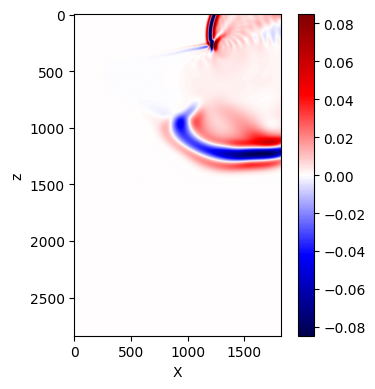

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
qa = np.quantile(snapsObj, 0.999)
matrice0 = ax.imshow(snapsObj[50, :, :].T, vmin=-qa, vmax=qa, cmap="seismic")
fig.colorbar(matrice0)

ax.set_xlabel('X')
ax.set_ylabel('z')

def update(i):
    matrice0.set_array(snapsObj[i, :, :].T)
    return matrice0,

plt.tight_layout()

# Animation
# ani = animation.FuncAnimation(fig, update, frames=nsnaps, interval=50, blit=True)
# plt.close(ani._fig)
plt.show()

In [5]:
# HTML(ani.to_html5_video())

In [6]:
print(snapsObj.T.shape)
snapsObj_sub = snapsObj.T[::4, ::4, :]
print(snapsObj_sub.shape)

(2838, 1826, 250)
(710, 457, 250)


torch.Size([710, 457, 126])
cuda:0


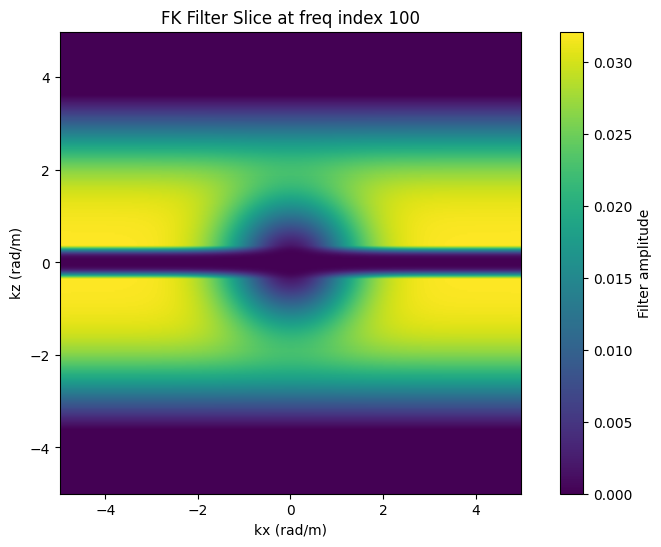

In [17]:
from examples.seismic.fk_filter import FKFilter3D


fk = FKFilter3D(dx=model.spacing[0]*4, dz=model.spacing[1]*4,
                dt=(tn/nsnaps)/1000, sigma_x=3, sigma_z=1, min_slope=0.5, max_slope=5, gaussian_sigma=1)
fk._compute_filter(*snapsObj_sub.shape)
print(fk.filter.shape)
print(fk.filter.device)
fk.plot_filter_slice(100)

In [18]:
snaps_filtered = fk(snapsObj_sub)
print(snaps_filtered.shape)

311.9142150878906
(710, 457, 250)


In [19]:
snaps_filtered = snaps_filtered.T
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
qa = np.quantile(snaps_filtered, 0.999)
matrice0 = ax.imshow(snaps_filtered[0, :, :].T, vmin=-qa, vmax=qa, cmap="seismic")
fig.colorbar(matrice0)

ax.set_xlabel('X')
ax.set_ylabel('z')

def update(i):
    matrice0.set_array(snaps_filtered[i, :, :].T)
    return matrice0,

plt.tight_layout()

# Animation
ani = animation.FuncAnimation(fig, update, frames=nsnaps, interval=50, blit=True)
plt.close(ani._fig)
# plt.show()

In [20]:
HTML(ani.to_html5_video())